### 0.项目说明

#### Credit Card Fraud Detection - 典型案例复现

本项目基于经典信用卡欺诈检测数据集（Kaggle），完成从数据分析、预处理、建模到评估的完整机器学习流程复现。

核心问题：
- 极端类别不平衡（欺诈 ≈ 0.17%）
- 目标：最大化 AUC / Recall / F1

方法：
- Logistic Regression（基线）
- Random Forest
- XGBoost
- SMOTE 处理类别不平衡

### 1.环境与依赖

In [1]:
# 基础库
import numpy as np
import pandas as pd

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 模型
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)

# 模型
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 不平衡处理
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# 固定随机种子
RANDOM_STATE = 42

### 2.数据加载与基本信息

In [2]:
df = pd.read_csv('creditcard.csv')

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# 类别分布
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

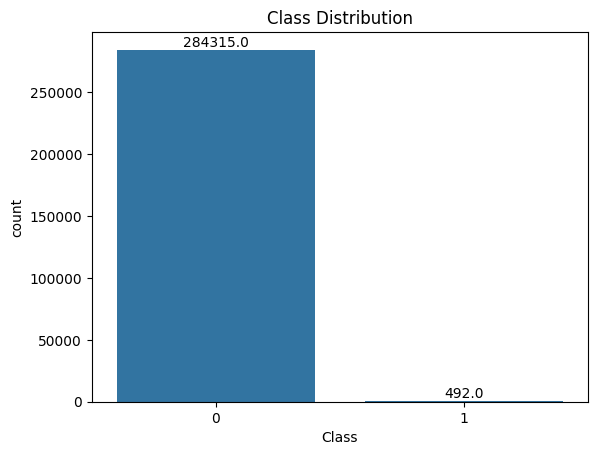

In [4]:
ax = sns.countplot(x='Class', data=df)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height,
            f'{height}', ha='center', va='bottom')

plt.title("Class Distribution")
plt.show()

### 3.数据质量检查

In [5]:
# 缺失值
df.isnull().sum().sum()

np.int64(0)

In [6]:
# 描述统计
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


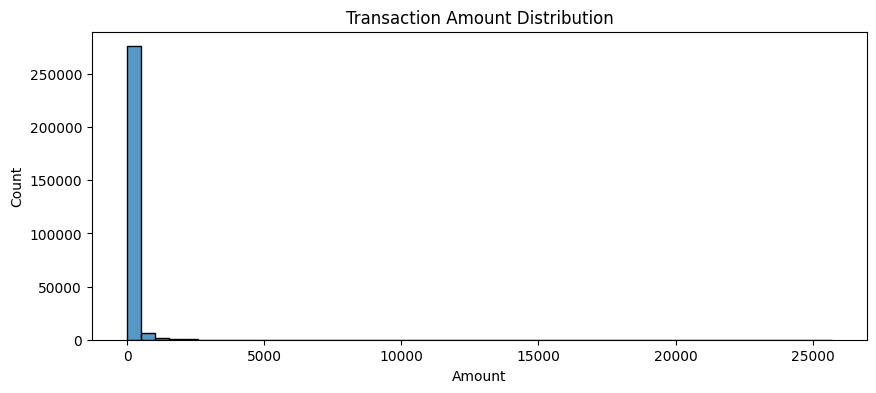

In [7]:
# 时间与金额分布
plt.figure(figsize=(10,4))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

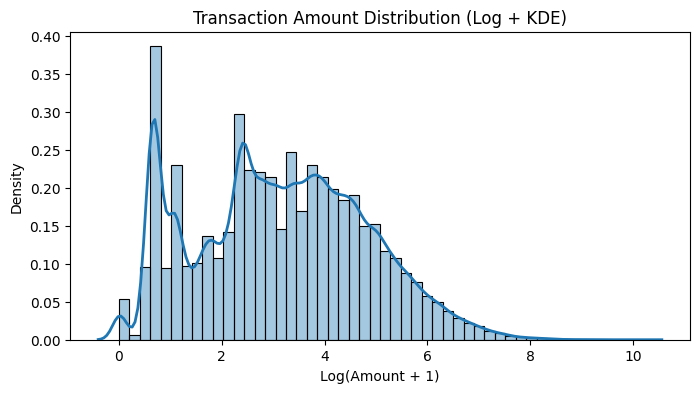

In [8]:
# 对数变换（解决长尾）
amount_log = np.log1p(df['Amount'])

plt.figure(figsize=(8,4))

# 直方图（浅色）
sns.histplot(
    amount_log,
    bins=50,
    stat='density',   # 关键：和KDE统一
    alpha=0.4,
    kde=False
)

# KDE（深色）
sns.kdeplot(
    amount_log,
    linewidth=2
)

plt.title("Transaction Amount Distribution (Log + KDE)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Density")

plt.show()
# 这个图是对数变换后的金额分布，结合了直方图和KDE。可以看到，经过对数变换后，金额的分布更接近正态分布，有助于模型更好地学习数据特征。

In [11]:
def evaluate_model(y_true, y_pred, y_prob):
    print(classification_report(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_prob))

print("Logistic Regression")
evaluate_model(y_test, y_pred_lr, y_prob_lr)

print("Random Forest")
evaluate_model(y_test, y_pred_rf, y_prob_rf)

print("XGBoost")
evaluate_model(y_test, y_pred_xgb, y_prob_xgb)

Logistic Regression


NameError: name 'y_test' is not defined

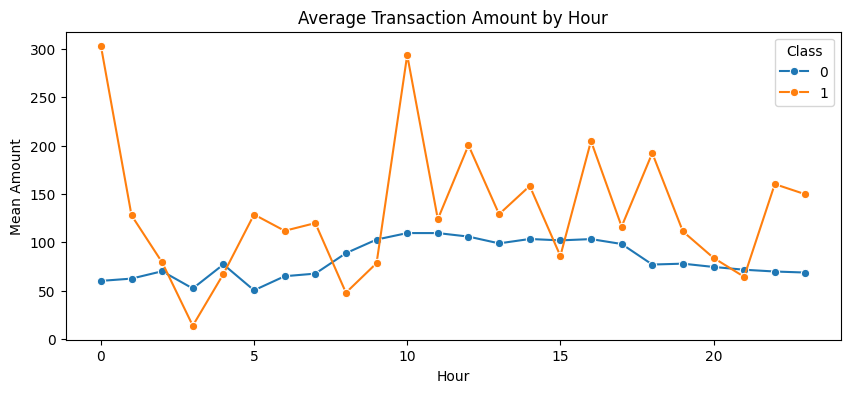

In [ ]:
df['Hour'] = (df['Time'] // 3600) % 24

hourly = df.groupby(['Hour','Class'])['Amount'].mean().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=hourly, x='Hour', y='Amount', hue='Class', marker='o')

plt.title("Average Transaction Amount by Hour")
plt.ylabel("Mean Amount")
plt.show()

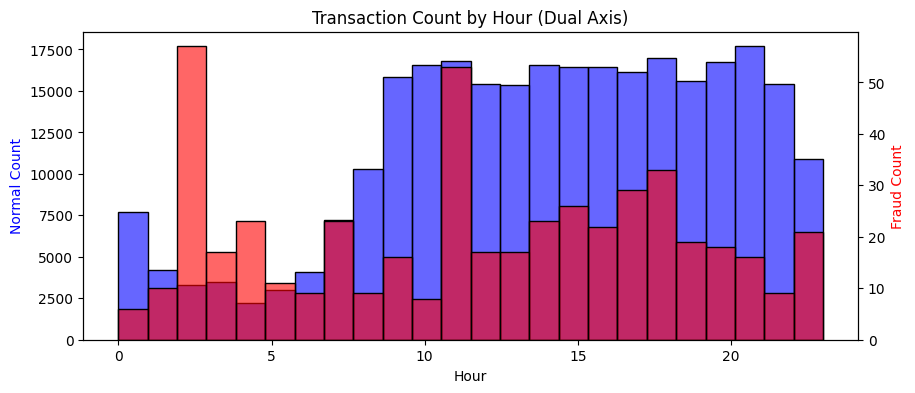

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,4))

# 正常交易
normal = df[df['Class']==0]['Hour']
sns.histplot(normal, bins=24, color='blue', alpha=0.6, ax=ax1)
ax1.set_ylabel("Normal Count", color='blue')

# 第二个轴
ax2 = ax1.twinx()

fraud = df[df['Class']==1]['Hour']
sns.histplot(fraud, bins=24, color='red', alpha=0.6, ax=ax2)
ax2.set_ylabel("Fraud Count", color='red')

plt.title("Transaction Count by Hour (Dual Axis)")
plt.xlabel("Hour")
plt.show()

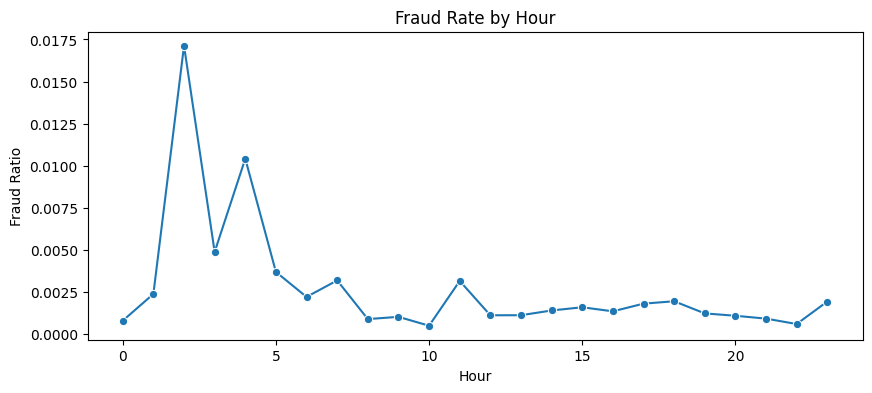

In [ ]:
hour_ratio = df.groupby('Hour')['Class'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hour_ratio.index, y=hour_ratio.values, marker='o')

plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Ratio")
plt.show()

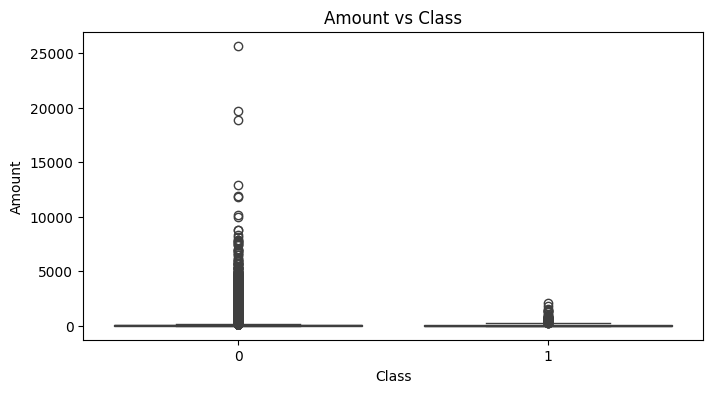

In [ ]:
# 金额对比
plt.figure(figsize=(8,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Class")
plt.show()

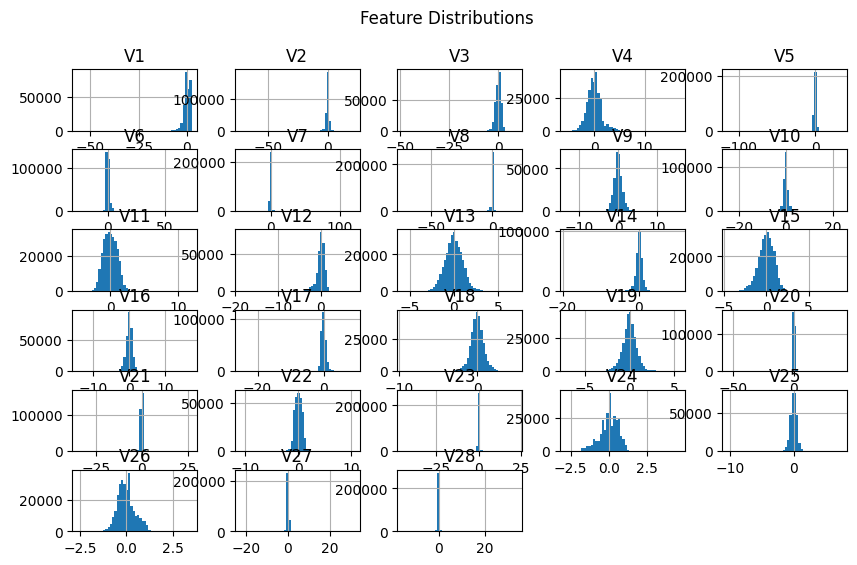

In [ ]:
# 特征分布
features = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
            'V11','V12','V13','V14','V15','V16','V17','V18','V19','V20',
            'V21','V22','V23','V24','V25','V26','V27','V28']

df[features].hist(figsize=(10,6), bins=50)
plt.suptitle("Feature Distributions")
plt.show()

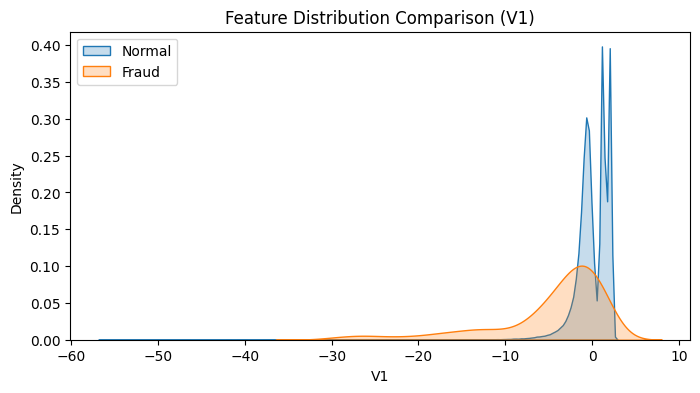

In [ ]:
# Fraud vs Normal 分布对比
plt.figure(figsize=(8,4))
sns.kdeplot(df[df['Class']==0]['V1'], label='Normal', fill=True)
sns.kdeplot(df[df['Class']==1]['V1'], label='Fraud', fill=True)
plt.title("Feature Distribution Comparison (V1)")
plt.legend()
plt.show()

### 4.数据预处理

In [ ]:
# 特征与标签
X = df.drop('Class', axis=1)
y = df['Class']

# 标准化 Amount
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X['Amount'].values.reshape(-1,1))

In [ ]:
# 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### 5.处理类别不平衡

In [ ]:
smote = SMOTE(random_state=RANDOM_STATE)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_res).value_counts())

Before: Class
0    227451
1       394
Name: count, dtype: int64
After: Class
0    227451
1    227451
Name: count, dtype: int64


### 6.基线模型：Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

c:\Users\Asus\anaconda3\envs\pyVirEnv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 7.Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

### 8.XGBoost（主模型）

In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

### 9.模型评估

In [ ]:
def evaluate_model(y_true, y_pred, y_prob):
    print(classification_report(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_prob))

In [ ]:
print("Logistic Regression")
evaluate_model(y_test, y_pred_lr, y_prob_lr)

print("Random Forest")
evaluate_model(y_test, y_pred_rf, y_prob_rf)

print("XGBoost")
evaluate_model(y_test, y_pred_xgb, y_prob_xgb)

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962

AUC: 0.9755785016595271
Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUC: 0.9691731363338808
XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.66      0.89      0.76        98

    accuracy                           1.00     56962
   macro avg       0.83      0.94     

### 10.混淆矩阵

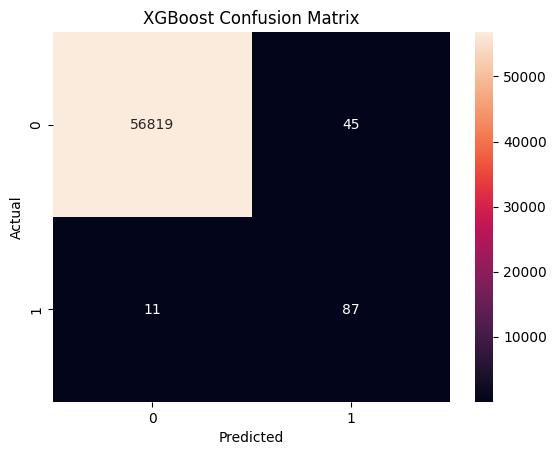

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")

### 11.ROC曲线

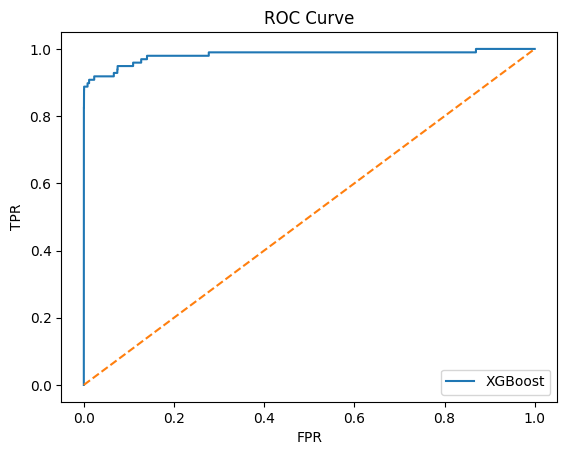

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr, tpr, label='XGBoost')
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 12.Precision-Recall曲线

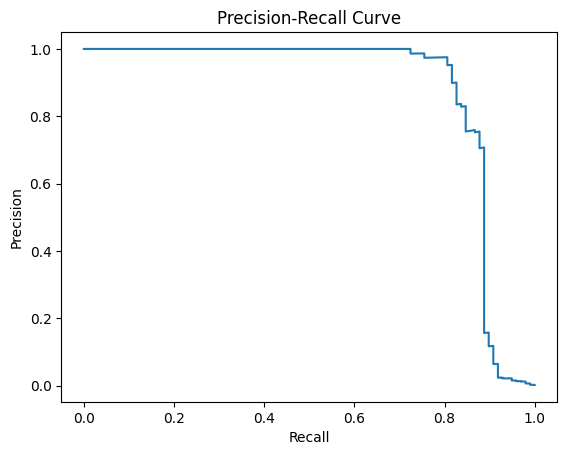

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### 13.特征重要性

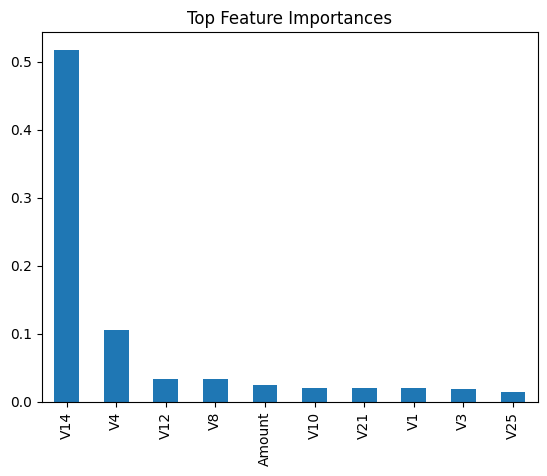

In [ ]:
importances = xgb.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

### 14.消融实验

In [ ]:
# 不使用 SMOTE
xgb_no_smote = XGBClassifier(random_state=RANDOM_STATE)
xgb_no_smote.fit(X_train, y_train)

y_prob_no = xgb_no_smote.predict_proba(X_test)[:,1]

print("Without SMOTE AUC:", roc_auc_score(y_test, y_prob_no))
print("With SMOTE AUC:", roc_auc_score(y_test, y_prob_xgb))

Without SMOTE AUC: 0.9389517272862999
With SMOTE AUC: 0.9817825273046753


### 15.可复现性

In [ ]:
# 保存模型结果
pd.DataFrame({
    'y_true': y_test,
    'y_prob': y_prob_xgb
}).to_csv("results.csv", index=False)

### 16.SHAP分析

c:\Users\Asus\anaconda3\envs\pyVirEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


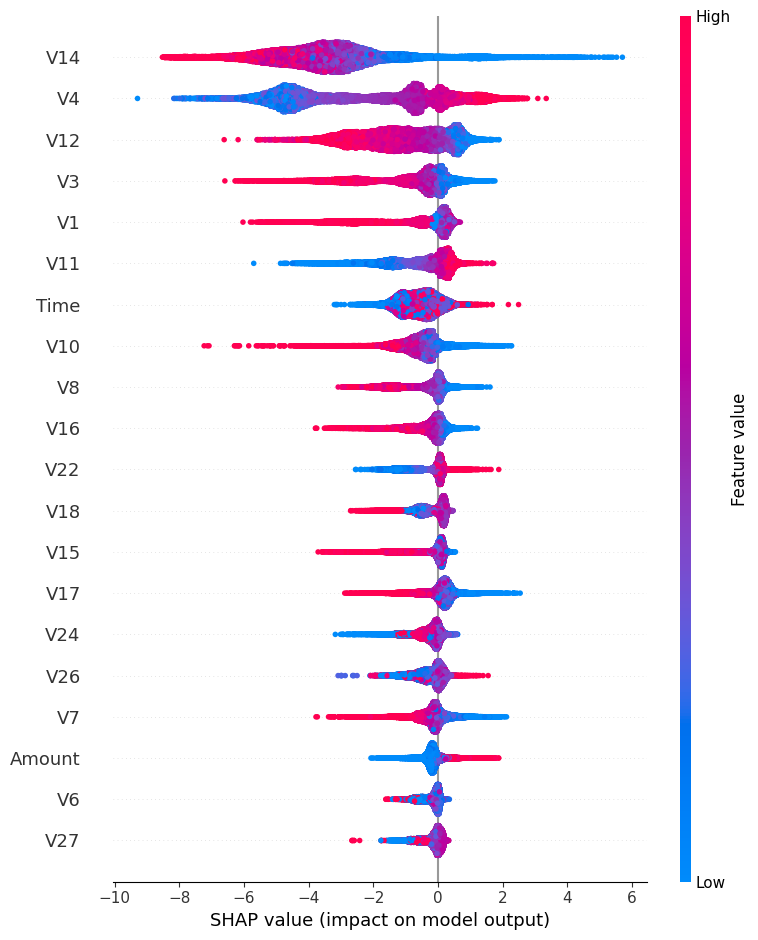

In [ ]:
# SHAP分析
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
